# Finite Size Scaling — Modelo de Ising 2D

Análisis de escalado de tamaño finito (FSS) para el modelo de Ising 2D simulado con tres algoritmos: **Metropolis**, **Glauber** y **Wolff**.

Se determinan:
- La temperatura crítica $T_c$ mediante el cruce del cumulante de Binder $U_4$.
- Los exponentes críticos $\nu$, $\beta/\nu$ y $\gamma/\nu$ mediante ajustes log-log.
- El colapso de datos como verificación del escalado.

## 1. Importaciones y carga de datos

Leemos los tres ficheros de simulación con columnas `L  T  e  m  Cv  m2  m4  mk2  tau`.

Columnas derivadas calculadas al leer:
- **$U_4$** (cumulante de Binder) $= 1 - \langle m^4\rangle / (3\langle m^2\rangle^2)$
- **$\chi$** (susceptibilidad) $= (L^2/T)\,(\langle m^2\rangle - \langle|m|\rangle^2)$
- **$\xi_L$** (longitud de correlación de segundo momento) $= \dfrac{1}{2 L \sin(\pi/L)}\sqrt{\dfrac{\langle m^2\rangle - \langle|m|\rangle^2}{\langle|m(k_1)|^2\rangle}-1}$

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.interpolate import interp1d, PchipInterpolator
from itertools import combinations
from scipy.optimize import brentq

plt.rcParams.update({
    'figure.figsize':    (7, 5),
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   9,
    'legend.framealpha': 0.85,
    'legend.edgecolor':  '0.8',
    'lines.linewidth':   1.4,
    'lines.markersize':  2,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

TC_EXACT = 2.2691853  # Onsager exact solution

ALGOS = {
    'Metropolis': 'metropolis_2d.txt',
    'Glauber':    'glauber_2d.txt',
    'Wolff':      'wolff_2d.txt',
}
COLS = ['L', 'T', 'e', 'm', 'c', 'm2', 'm4', 'mk2', 'tau']

# Consistent per-L colors and markers used across all plots
L_COLORS  = {16: '#e41a1c', 32: '#377eb8', 64: '#4daf4a', 128: '#984ea3'}
L_MARKERS = {16: 'o',       32: 's',       64: '^',       128: 'D'}


def _load(fname):
    df = pd.read_csv(fname, sep=r'\s+', header=None, names=COLS)
    m2_conn = df['m2'] - df['m']**2
    df['U4']  = 1.0 - df['m4'] / (3.0 * df['m2']**2)
    df['chi'] = (df['L']**2 / df['T']) * m2_conn
    df['xi']  = (np.sqrt(np.maximum(m2_conn / df['mk2'] - 1.0, 0.0))
                 / (2.0 * np.sin(np.pi / df['L'])))
    return df


data = {algo: _load('datos/' + fname) for algo, fname in ALGOS.items()}
L_values = sorted(data['Glauber']['L'].unique())


def slice_L(df, L):
    """Subset of df at a given L, sorted by T."""
    return df[df['L'] == L].sort_values('T')


print('Tamaños de red:', L_values)

Tamaños de red: [16, 32, 64, 128]


## 2. Funciones auxiliares

- **`find_Tc`** — localiza $T_c$ interpolando los cruces del cumulante de Binder $U_4(T)$ entre pares consecutivos de $L$, y extrapola $T_c(L\to\infty)$ ajustando $T_{cross}$ frente a $1/L^2$.
- **`get_exponents`** — extrae los exponentes críticos mediante ajustes log-log:
  - $1/\nu$: pendiente de $\ln|\partial U_4/\partial T|_{T_c}$ vs $\ln L$
  - $\beta/\nu$: pendiente (negada) de $\ln\langle|m|\rangle(T_c)$ vs $\ln L$
  - $\gamma/\nu$: pendiente de $\ln\chi_{\max}$ vs $\ln L$

In [121]:
def find_Tc(df, L_values, t_window=(1.8, 2.8)):
    """Cruces de Binder → estimadores de Tc.

    - Tc_mean:    media de cruces entre todos los pares posibles de L.
    - Tc_inf:     extrapolación lineal de cruces consecutivos vs 1/L2².
    - Tc_inf_2pt: extrapolación lineal usando solo el primer y último par consecutivo.
    """
    interps = {L: PchipInterpolator(slice_L(df, L)['T'].values,
                                    slice_L(df, L)['U4'].values,
                                    extrapolate=False)
               for L in L_values}

    def _find_crossings(pairs):
        crossings, inv_L2 = [], []
        for L1, L2 in pairs:
            s1, s2 = slice_L(df, L1), slice_L(df, L2)
            T_lo = max(s1['T'].min(), s2['T'].min(), t_window[0])
            T_hi = min(s1['T'].max(), s2['T'].max(), t_window[1])
            Ts   = np.linspace(T_lo, T_hi, 2000)
            diff = interps[L1](Ts) - interps[L2](Ts)
            roots = []
            for j in range(len(diff) - 1):
                if diff[j] == 0:
                    roots.append(Ts[j])
                elif diff[j] * diff[j+1] < 0:
                    roots.append(brentq(
                        lambda t, _j=j: interps[L1](t) - interps[L2](t),
                        Ts[j], Ts[j+1],
                    ))
            if roots:
                crossings.append(float(np.median(roots)))
                inv_L2.append(1.0 / L2**2)
        return np.array(crossings), np.array(inv_L2)

    # Tc_mean: todos los pares
    all_crossings, _ = _find_crossings(combinations(L_values, 2))
    tc_mean = float(np.mean(all_crossings)) if len(all_crossings) else np.nan

    # Tc_inf: solo pares consecutivos, extrapolación lineal completa
    consec_crossings, inv_L2 = _find_crossings(zip(L_values[:-1], L_values[1:]))
    if len(consec_crossings) >= 2:
        slope, tc_inf = np.polyfit(inv_L2, consec_crossings, 1)
    elif len(consec_crossings) == 1:
        slope, tc_inf = np.nan, float(consec_crossings[0])
    else:
        slope, tc_inf = np.nan, np.nan

    # Tc_inf_2pt: solo primer y último par consecutivo
    if len(consec_crossings) >= 2:
        x2 = np.array([inv_L2[0], inv_L2[-1]])
        y2 = np.array([consec_crossings[0], consec_crossings[-1]])
        slope_2pt, tc_inf_2pt = np.polyfit(x2, y2, 1)
    else:
        slope_2pt, tc_inf_2pt = np.nan, tc_inf

    return {
        'Tc_mean':     tc_mean,
        'Tc_inf':      float(tc_inf),
        'Tc_inf_2pt':  float(tc_inf_2pt),
        'slope':       float(slope) if not np.isnan(slope) else np.nan,
        'crossings':   consec_crossings,
        'inv_L2':      inv_L2,
    }


def get_exponents(df, L_values, Tc, dT_coef=0.05):
    """Ajustes log-log para ν, β/ν y γ/ν.

    Usa PCHIP (monótono por tramos) para U4 y ⟨|m|⟩, evitando el sobreimpulso
    cúbico cerca del salto en Tc. El paso para la derivada de U4 escala como
    dT = dT_coef / L, adaptándose a la resolución de la malla fina.
    """
    log_L = np.log(np.array(L_values, dtype=float))

    interp_U4 = {L: PchipInterpolator(slice_L(df, L)['T'].values,
                                      slice_L(df, L)['U4'].values,
                                      extrapolate=False)
                 for L in L_values}
    interp_m  = {L: PchipInterpolator(slice_L(df, L)['T'].values,
                                      slice_L(df, L)['m'].values,
                                      extrapolate=False)
                 for L in L_values}

    # 1/ν — pendiente de log|dU4/dT|_{Tc} vs log L, con dT ∝ 1/L
    Ls_dU, log_dU = [], []
    for L in L_values:
        dT   = dT_coef / L
        sLT  = slice_L(df, L)['T']
        if sLT.min() < Tc - dT and Tc + dT < sLT.max():
            deriv = (interp_U4[L](Tc + dT) - interp_U4[L](Tc - dT)) / (2 * dT)
            Ls_dU.append(L)
            log_dU.append(np.log(abs(deriv)))
    inv_nu = np.polyfit(np.log(np.array(Ls_dU, float)), log_dU, 1)[0]

    # β/ν — pendiente de log⟨|m|⟩(Tc) vs log L (β/ν = -slope)
    Ls_m = [L for L in L_values
            if slice_L(df, L)['T'].min() <= Tc <= slice_L(df, L)['T'].max()]
    log_m   = [np.log(float(interp_m[L](Tc))) for L in Ls_m]
    slope_m = np.polyfit(np.log(np.array(Ls_m, float)), log_m, 1)[0]

    # γ/ν — pendiente de log χ_max vs log L
    log_chi  = [np.log(slice_L(df, L)['chi'].max()) for L in L_values]
    gamma_nu = np.polyfit(log_L, log_chi, 1)[0]

    return 1.0 / inv_nu, -slope_m, gamma_nu

## 3. Temperatura crítica y exponentes críticos

Se aplican `find_Tc` y `get_exponents` a los datos de cada algoritmo. Los valores de referencia exactos (Onsager) son:

$$T_c = 2.2691853, \quad \nu = 1, \quad \beta/\nu = 1/8, \quad \gamma/\nu = 7/4.$$

In [122]:
fits = {algo: find_Tc(df, L_values) for algo, df in data.items()}

results_list = []
for algo, df in data.items():
    res = fits[algo]
    Tc  = res['Tc_inf'] if not np.isnan(res['Tc_inf']) else res['Tc_mean']
    nu, beta_nu, gamma_nu = get_exponents(df, L_values, Tc)
    results_list.append({'Tc': round(Tc, 6), 'Tc_mean': round(res['Tc_mean'], 6),
                         'Tc_2pt': round(res['Tc_inf_2pt'], 6),
                         'ν': round(nu, 4), 'β/ν': round(beta_nu, 4),
                         'γ/ν': round(gamma_nu, 4)})

results = pd.DataFrame(results_list, index=list(data.keys()))
results.index.name = 'Algoritmo'

exact = pd.Series({'Tc': TC_EXACT, 'Tc_mean': TC_EXACT, 'Tc_2pt': TC_EXACT,
                   'ν': 1.0, 'β/ν': 0.125, 'γ/ν': 1.75},
                  name='Onsager (exacto)')
display(pd.concat([results, exact.to_frame().T]))

,Tc,Tc_mean,Tc_2pt,ν,β/ν,γ/ν
Metropolis,2.272591,2.270066,2.273460,0.9798,0.1381,1.7792
Glauber,2.269321,2.269947,2.274737,3.5411,0.1214,1.7741
Wolff,2.271958,2.274373,2.271521,1.0728,0.1257,1.7803
Onsager (exacto),2.269185,2.269185,2.269185,1.0000,0.1250,1.7500


### 3.1 Cumulante de Binder $U_4(T)$

Curvas $U_4(T)$ para cada algoritmo y tamaño $L$. El cruce de las curvas de distintos $L$ señala $T_c$; la recta $T_{cross}$ vs $1/L^2$ extrapola al valor en tamaño infinito.

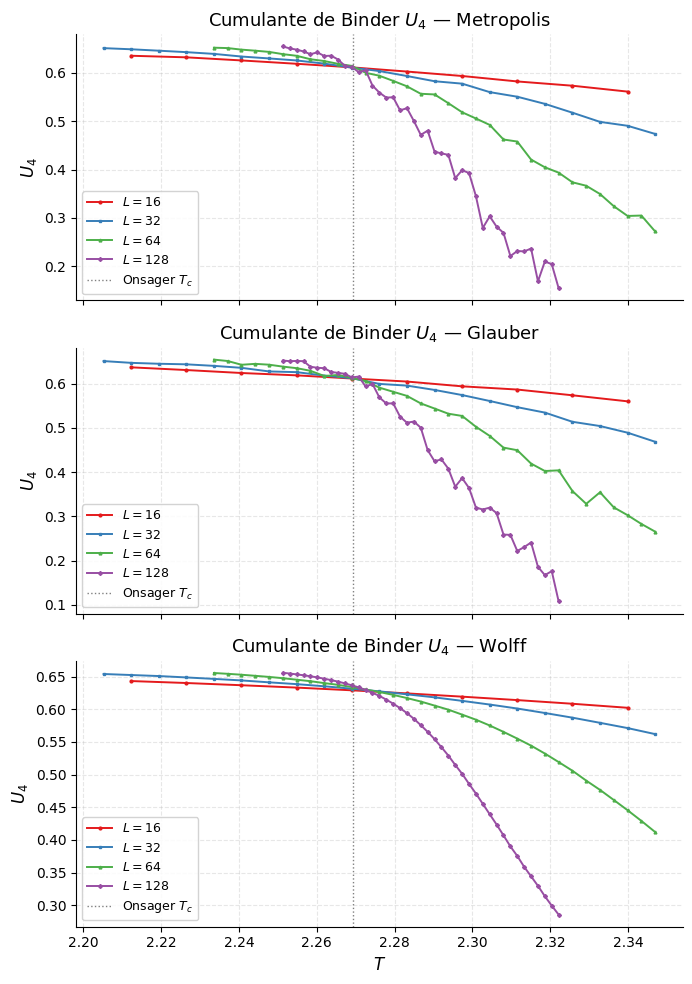

In [123]:
T_ZOOM = (2.20, 2.35)

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        s_zoom = s[(s['T'] >= T_ZOOM[0]) & (s['T'] <= T_ZOOM[1])]
        ax.plot(s_zoom['T'], s_zoom['U4'],
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.4, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='gray', ls=':',  lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_ylabel(r'$U_4$')
    ax.set_title(fr'Cumulante de Binder $U_4$ — {algo}')
    ax.legend(loc='lower left')
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/fss_binder.svg', bbox_inches='tight')
plt.show()

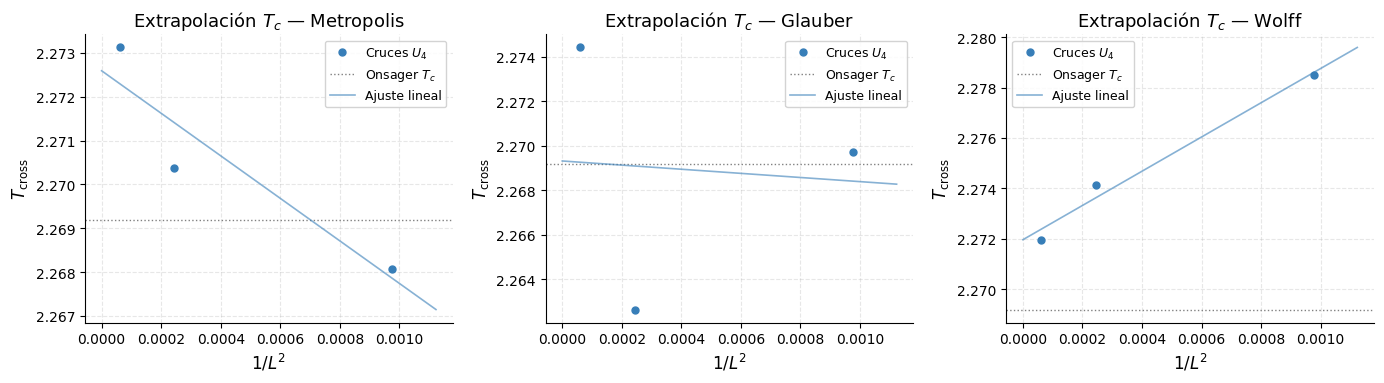

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, algo in zip(axes, data):
    res  = fits[algo]
    x, y = res['inv_L2'], res['crossings']
    ax.plot(x, y, 'o', ms=5, color='#377eb8',
            label='Cruces $U_4$', zorder=3)
    ax.axhline(TC_EXACT, color='gray', ls=':',  lw=1.0,
               label=r'Onsager $T_c$')
    if len(x) >= 2 and not np.isnan(res['slope']):
        xx = np.linspace(0, max(x) * 1.15, 200)
        ax.plot(xx, res['Tc_inf'] + res['slope'] * xx,
                '-', color='#377eb8', lw=1.2, alpha=0.6, label='Ajuste lineal')
    ax.set_xlabel(r'$1/L^2$')
    ax.set_ylabel(r'$T_\mathrm{cross}$')
    ax.set_title(fr'Extrapolación $T_c$ — {algo}')
    ax.legend()
plt.tight_layout()
plt.savefig('Gráficas/extrp_lin.svg', bbox_inches='tight')
plt.show()

In [125]:
all_crossings    = np.concatenate([fits[algo]['crossings'] for algo in data])
all_extrapolated = np.array([fits[algo]['Tc_inf'] for algo in data])

print(f"Media de cruces individuales (todos los pares L): {all_crossings.mean():.6f}")
print(f"Media de Tc extrapolados (uno por algoritmo):     {all_extrapolated.mean():.6f}")

Media de cruces individuales (todos los pares L): 2.271436
Media de Tc extrapolados (uno por algoritmo):     2.271290


### 3.2 Capacidad calorífica y Magnetización

Evolución de la capacidad calorífica $C_v$ y la magnetización absoluta por espín $\langle |m| \rangle$ en función de la temperatura $T$.

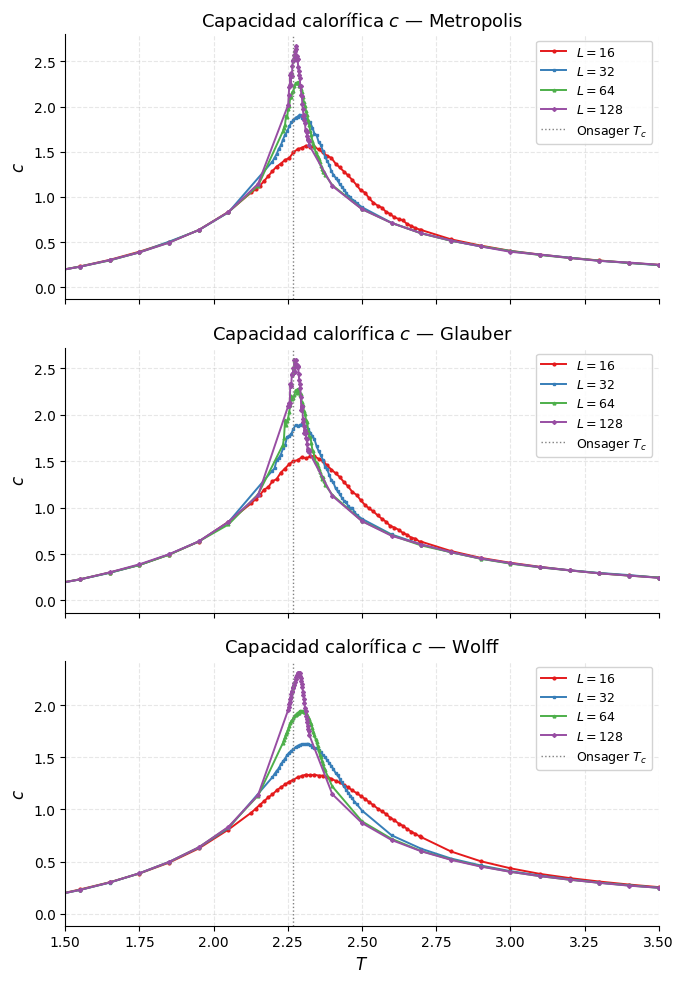

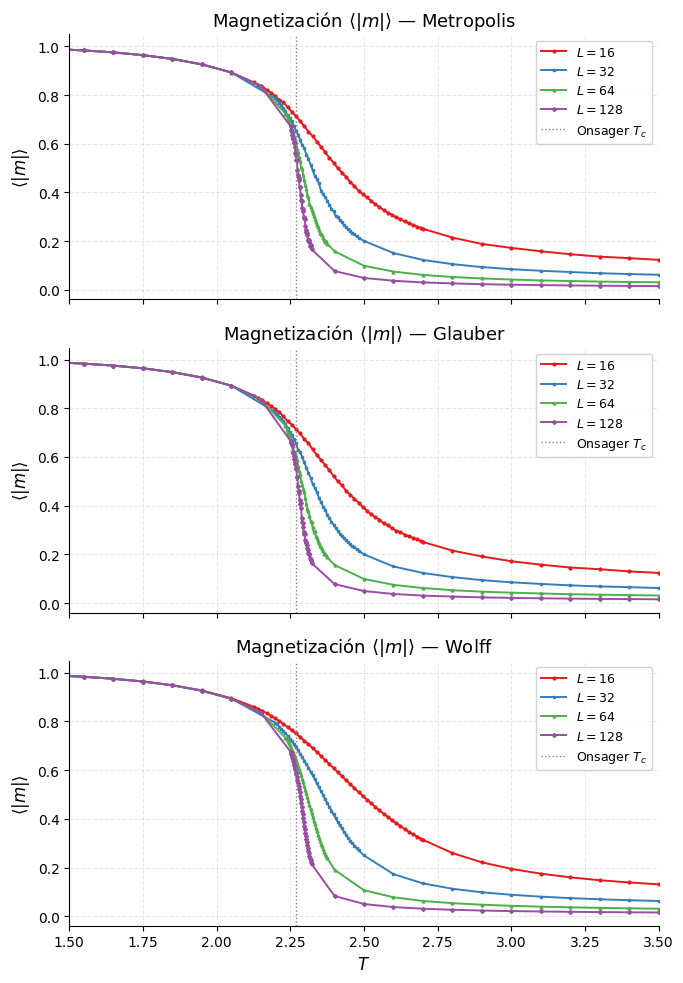

In [126]:
# Capacidad calorífica c
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        ax.plot(s['T'], s['c'],
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.4, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='gray', ls=':',  lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_xlim(1.5, 3.5)
    ax.set_ylabel(r'$c$')
    ax.set_title(fr'Capacidad calorífica $c$ — {algo}')
    ax.legend(loc='upper right')
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/c.svg', bbox_inches='tight')
plt.show()

# Magnetización |m|
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        ax.plot(s['T'], s['m'],
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.4, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='gray', ls=':',  lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_xlim(1.5, 3.5)
    ax.set_ylabel(r'$\langle |m| \rangle$')
    ax.set_title(fr'Magnetización $\langle |m| \rangle$ — {algo}')
    ax.legend(loc='upper right')
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/m.svg', bbox_inches='tight')
plt.show()

## 4. Susceptibilidad $\chi$

La susceptibilidad $\chi = (L^2/T)\,(\langle m^2\rangle - \langle|m|\rangle^2)$ diverge en $T_c$ como $\chi \sim |T-T_c|^{-\gamma}$. Para tamaño finito, el máximo crece como $\chi_{\max} \sim L^{\gamma/\nu}$, permitiendo extraer $\gamma/\nu$ por ajuste log-log.

El **colapso FSS** verifica que $\chi\,L^{-\gamma/\nu}$ es función universal de $\frac{T-T_c}{T_c}\,L^{1/\nu}$. El simulador genera puntos finos en $\frac{T-T_c}{T_c}\,L \in [-1,\,3]$, que es exactamente el rango mostrado.

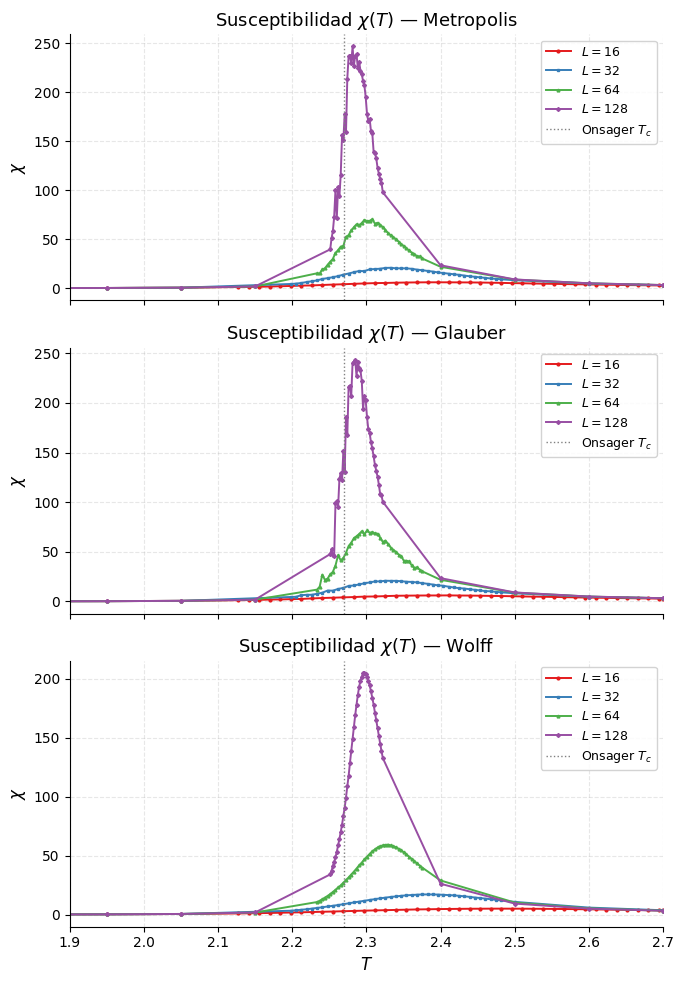

In [127]:
T_CHI = (1.9, 2.7)

fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        ax.plot(s['T'], s['chi'],
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.4, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='gray', ls=':',  lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_ylabel(r'$\chi$')
    ax.set_title(fr'Susceptibilidad $\chi(T)$ — {algo}')
    ax.set_xlim(*T_CHI)
    ax.legend()
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/suscept.svg', bbox_inches='tight')
plt.show()

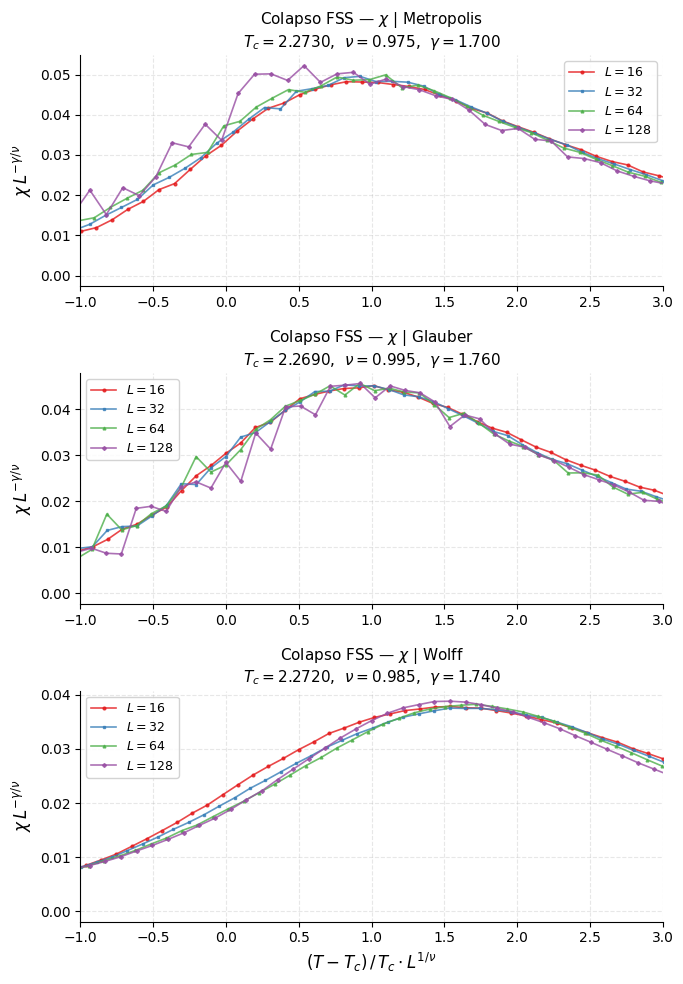

In [128]:
FSS_PARAMS = {
    'Metropolis': {'Tc': 2.273, 'nu': 0.975, 'gamma': 1.7},
    'Glauber':    {'Tc': 2.269, 'nu': 0.995, 'gamma': 1.76},
    'Wolff':      {'Tc': 2.272, 'nu': 0.985, 'gamma': 1.74},
}

fig, axes = plt.subplots(3, 1, figsize=(7, 10))
for ax, (algo, params) in zip(axes, FSS_PARAMS.items()):
    Tc, nu, gamma = params['Tc'], params['nu'], params['gamma']
    df = data[algo]
    for L in L_values:
        s = slice_L(df, L)
        x = ((s['T'].values - Tc) / Tc) * (L ** (1.0 / nu))
        y = s['chi'].values * (L ** (-gamma / nu))
        ax.plot(x, y,
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, alpha=0.8, lw=1.2, label=f'$L={L}$')
    ax.set_title(
        fr"Colapso FSS — $\chi$ | {algo}"
        f"\n$T_c={Tc:.4f}$,  $\\nu={nu:.3f}$,  $\\gamma={gamma:.3f}$",
        fontsize=11,
    )
    ax.set_ylabel(r'$\chi\,L^{-\gamma/\nu}$')
    ax.set_xlim(-1, 3)
    ax.legend()
axes[-1].set_xlabel(r'$(T - T_c)\,/\,T_c \cdot L^{1/\nu}$')
plt.tight_layout()
plt.savefig('Gráficas/suscept_fss.svg', bbox_inches='tight')
plt.show()

Para cuantificar el crecimiento del pico con $L$, se puede extraer $\chi_{\max}(L)$ para cada tamaño y representarla en escala logarítmica frente a $\ln L$: la pendiente debe ser $\gamma/\nu = 7/4 = 1{,}75$ según la predicción teórica. Los valores obtenidos son consistentes con esta pendiente, aunque con cuatro puntos el ajuste tiene una incertidumbre apreciable. Esta comprobación es independiente del colapso FSS y constituye una verificación directa de la ley de potencias $\chi_{\max} \sim L^{\gamma/\nu}$ sin necesidad de reescalar las variables.

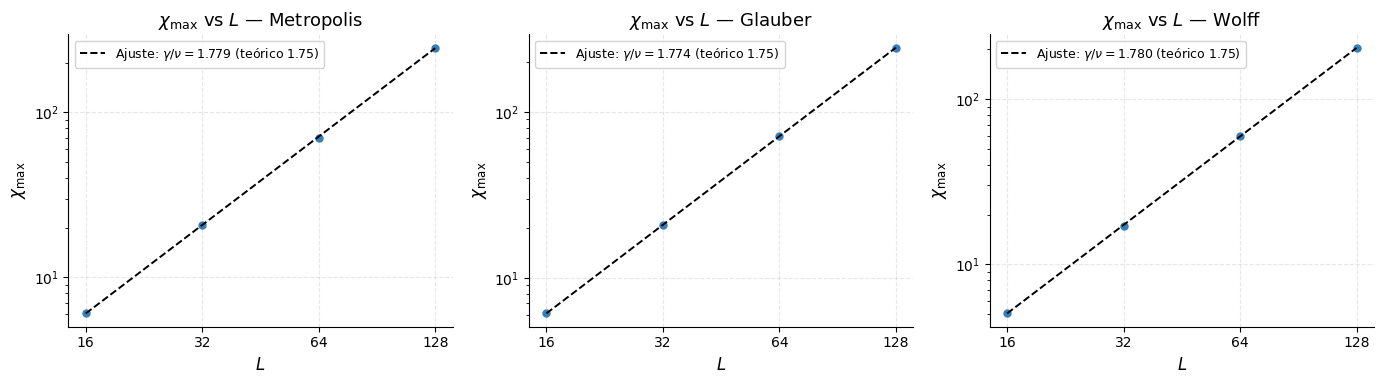

In [129]:
import matplotlib.ticker as mticker

L_arr = np.array(L_values, dtype=float)
log_L = np.log(L_arr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (algo, df) in zip(axes, data.items()):
    chi_max = np.array([slice_L(df, L)['chi'].max() for L in L_values])
    slope, intercept = np.polyfit(log_L, np.log(chi_max), 1)
    L_fit = np.geomspace(L_arr[0], L_arr[-1], 50)
    ax.plot(L_arr, chi_max, 'o', color='#377eb8', ms=5)
    ax.plot(L_fit, np.exp(intercept) * L_fit**slope, 'k--', lw=1.4,
            label=fr'Ajuste: $\gamma/\nu = {slope:.3f}$ (teórico 1.75)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(L_arr)
    fmt = mticker.ScalarFormatter()
    fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlabel(r'$L$')
    ax.set_ylabel(r'$\chi_{\max}$')
    ax.set_title(fr'$\chi_{{\max}}$ vs $L$ — {algo}')
    ax.legend()
plt.tight_layout()
plt.savefig('Gráficas/chi_scaling.svg', bbox_inches='tight')
plt.show()

## 5. Longitud de correlación $\xi_L$

La longitud de correlación de segundo momento se obtiene del cociente del factor de estructura en $k=0$ y $k_1=2\pi/L$:

$$\xi_L = \frac{1}{2\sin(\pi/L)}\sqrt{\frac{\langle m^2\rangle}{\langle|m(k_1)|^2\rangle} - 1}$$

En el límite termodinámico $\xi_L/L$ es función universal de $\frac{T-T_c}{T_c}\,L^{1/\nu}$, lo que proporciona un estimador de $T_c$ y $\nu$ independiente del cumulante de Binder. Adicionalmente, en $T_c$ se cumple $\xi_L \sim L$ con pendiente cercana a 1 en escala log-log.

**Nota:** la fórmula asume forma Ornstein-Zernike y es idónea para $T \gtrsim T_c$; usar la versión "conectada" (restando $\langle |m| \rangle^2$ en el numerador) en o cerca de $T_c$ reduce artificialmente el estimador porque la simetría no está verdaderamente rota en un sistema finito.

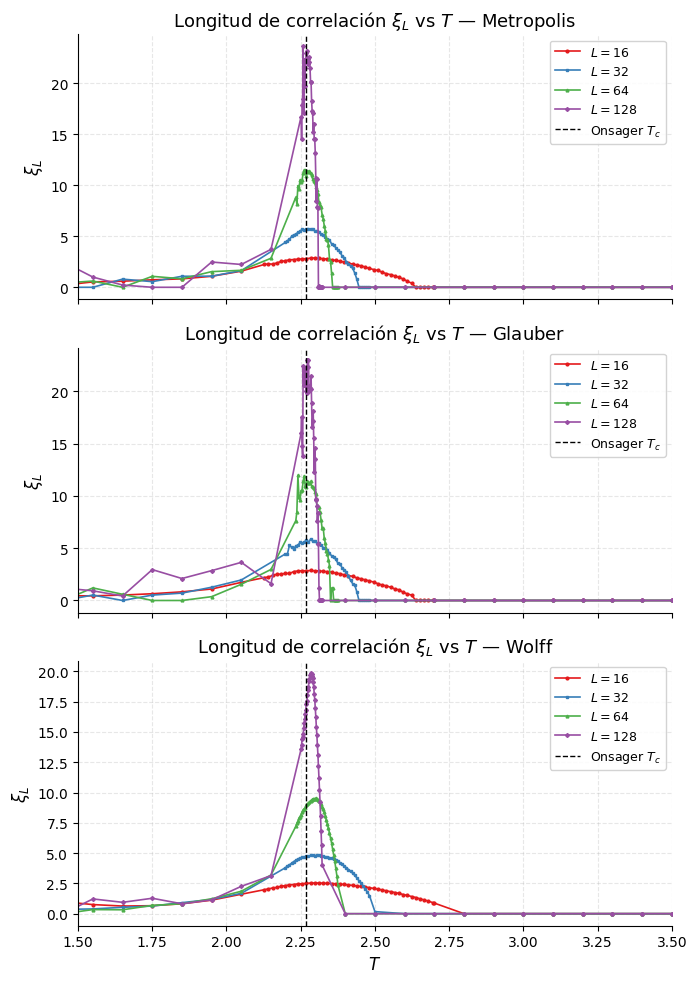

In [130]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        ax.plot(s['T'], s['xi'],
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.2, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='k', ls='--', lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_ylabel(r'$\xi_L$')
    ax.set_title(fr'Longitud de correlación $\xi_L$ vs $T$ — {algo}')
    ax.set_xlim(1.5, 3.5)
    ax.legend()
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/xi_vs_T.svg', bbox_inches='tight')
plt.show()

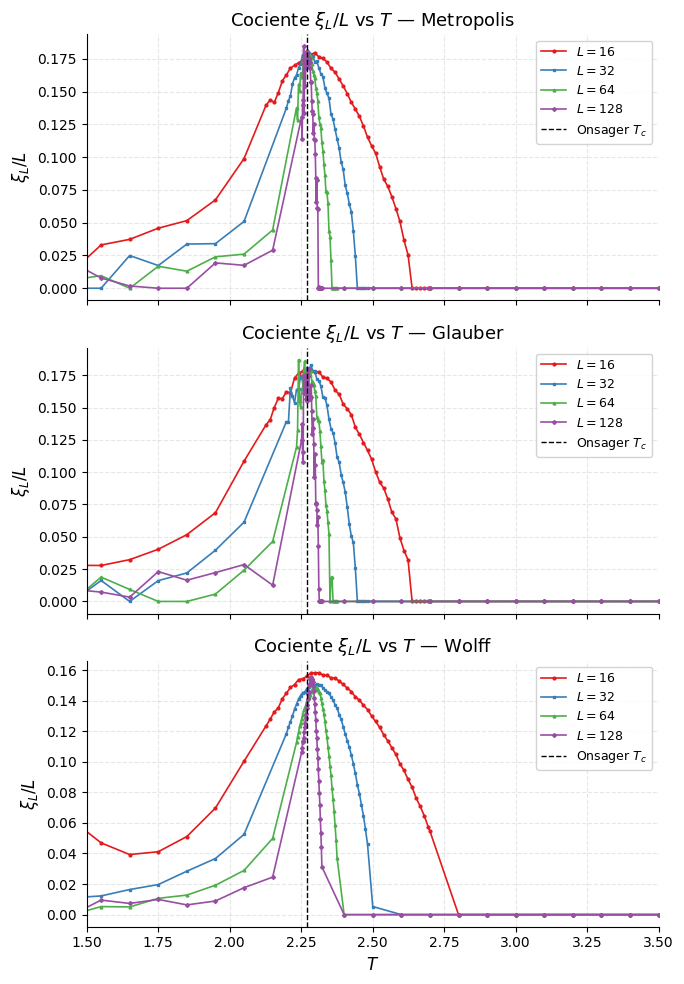

In [131]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        ax.plot(s['T'], s['xi'] / L,
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.2, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='k', ls='--', lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_ylabel(r'$\xi_L / L$')
    ax.set_title(fr'Cociente $\xi_L/L$ vs $T$ — {algo}')
    ax.set_xlim(1.5, 3.5)
    ax.legend()
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/xi_ratio.svg', bbox_inches='tight')
plt.show()

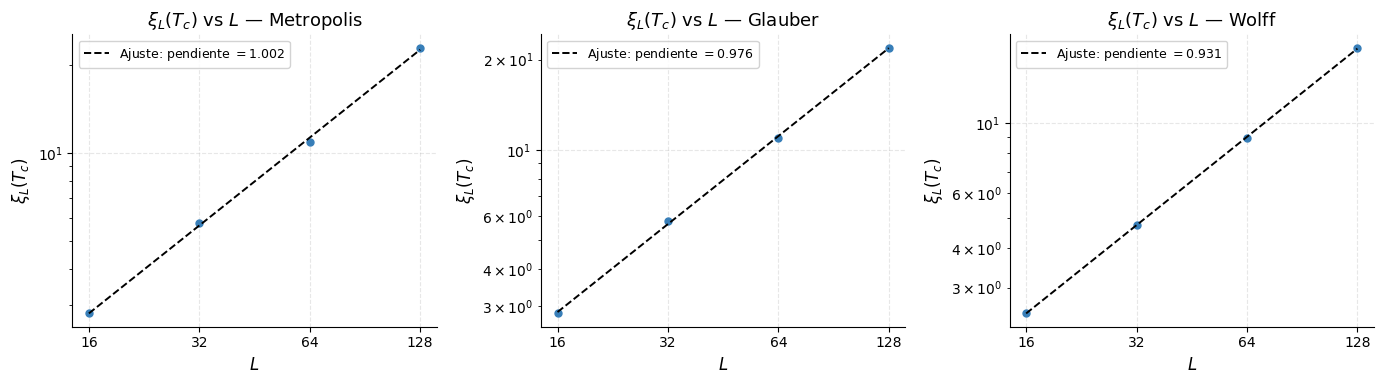

In [132]:
import matplotlib.ticker as mticker

L_arr = np.array(L_values, dtype=float)
log_L = np.log(L_arr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (algo, df) in zip(axes, data.items()):
    xi_at_Tc = []
    for L in L_values:
        s = slice_L(df, L)
        f_xi = interp1d(s['T'].values, s['xi'].values,
                        kind='cubic', bounds_error=False,
                        fill_value='extrapolate')
        xi_at_Tc.append(float(f_xi(TC_EXACT)))
    xi_arr = np.array(xi_at_Tc)
    slope, intercept = np.polyfit(log_L, np.log(xi_arr), 1)
    L_fit = np.geomspace(L_arr[0], L_arr[-1], 50)
    ax.plot(L_arr, xi_arr, 'o', color='#377eb8', ms=5)
    ax.plot(L_fit, np.exp(intercept) * L_fit**slope, 'k--', lw=1.4,
            label=fr'Ajuste: pendiente $= {slope:.3f}$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(L_arr)
    fmt = mticker.ScalarFormatter()
    fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlabel(r'$L$')
    ax.set_ylabel(r'$\xi_L(T_c)$')
    ax.set_title(fr'$\xi_L(T_c)$ vs $L$ — {algo}')
    ax.legend()
plt.tight_layout()
plt.savefig('Gráficas/xi_scaling.svg', bbox_inches='tight')
plt.show()

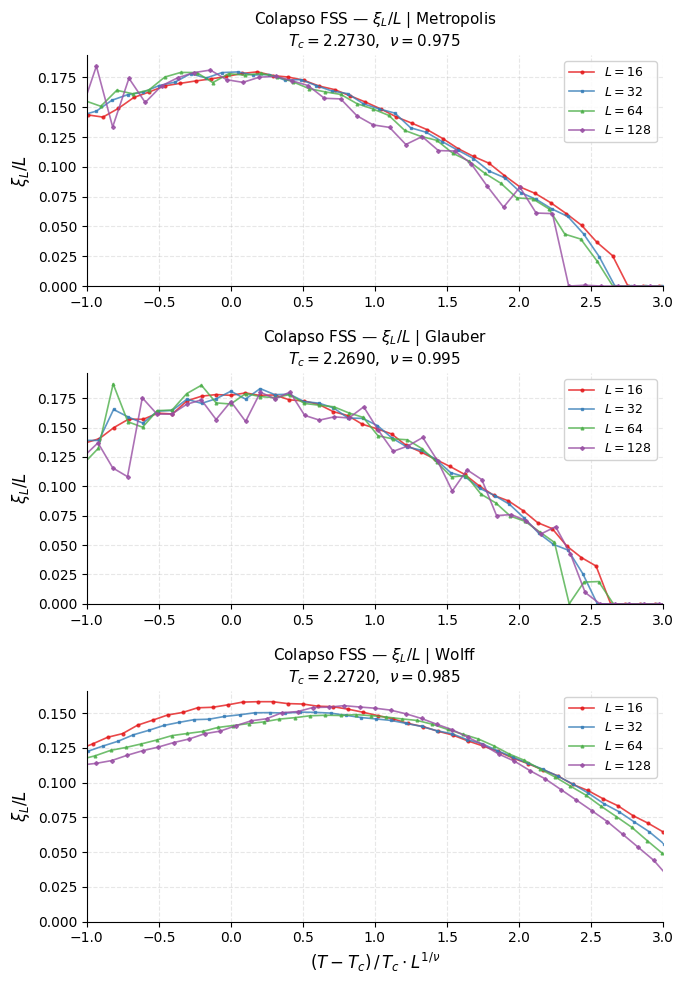

In [133]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10))
for ax, (algo, params) in zip(axes, FSS_PARAMS.items()):
    Tc, nu = params['Tc'], params['nu']
    df = data[algo]
    for L in L_values:
        s = slice_L(df, L)
        x = ((s['T'].values - Tc) / Tc) * (L ** (1.0 / nu))
        y = s['xi'].values / L
        ax.plot(x, y,
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, alpha=0.8, lw=1.2, label=f'$L={L}$')
    ax.set_title(
        fr"Colapso FSS — $\xi_L/L$ | {algo}"
        f"\n$T_c={Tc:.4f}$,  $\\nu={nu:.3f}$",
        fontsize=11,
    )
    ax.set_ylabel(r'$\xi_L / L$')
    ax.set_xlim(-1, 3)
    ax.set_ylim(bottom=0)
    ax.legend()
axes[-1].set_xlabel(r'$(T - T_c)\,/\,T_c \cdot L^{1/\nu}$')
plt.tight_layout()
plt.savefig('Gráficas/xi_fss.svg', bbox_inches='tight')
plt.show()

## 6. Tiempo de autocorrelación integrado $\tau_\text{int}$

El tiempo de autocorrelación integrado $\tau_\text{int}$ mide cuántos pasos MC son necesarios para que las muestras sean estadísticamente independientes. Se calcula mediante el método de ventana de Madras-Sokal a partir de la serie temporal $|m(t)|$.

Las unidades son pasos MC por spin para Metropolis y Glauber, y sweeps de Wolff para Wolff (un sweep = suficientes clusters para voltear ~$N$ spins).

El escalado dinámico predice $\tau_\text{int} \sim L^z$ en $T_c$, con:
- Metropolis/Glauber: $z \approx 2.17$ (ralentización crítica)
- Wolff: $z \approx 0$ (sin ralentización crítica)

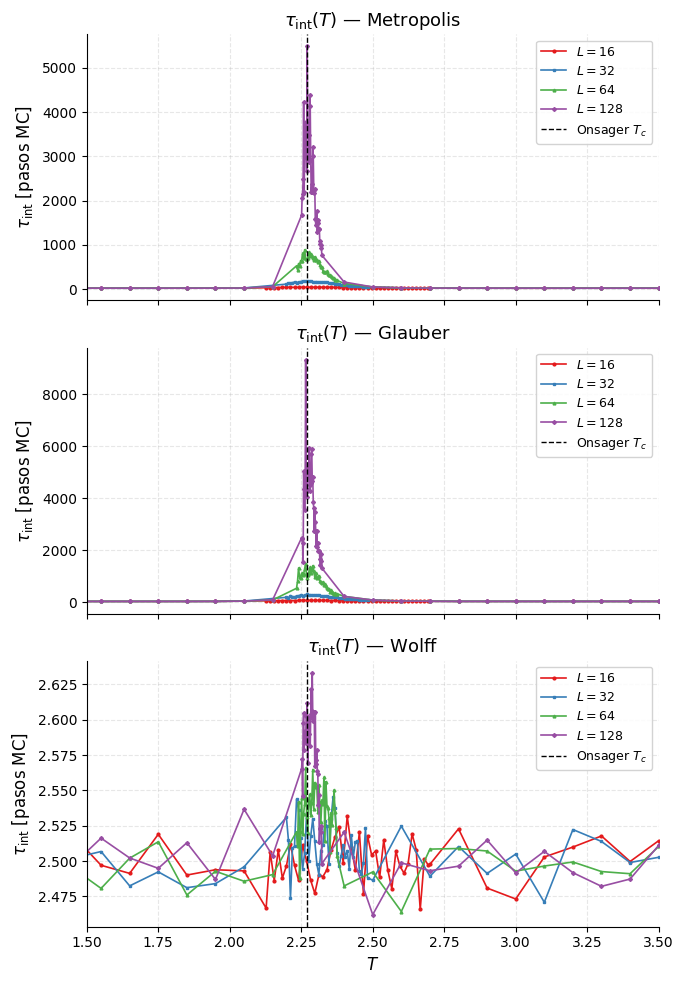

In [134]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
for ax, (algo, df) in zip(axes, data.items()):
    for L in L_values:
        s = slice_L(df, L)
        ax.plot(s['T'], s['tau'],
                color=L_COLORS[L], marker=L_MARKERS[L],
                ms=2, lw=1.2, label=f'$L={L}$')
    ax.axvline(TC_EXACT, color='k', ls='--', lw=1.0,
               label=r'Onsager $T_c$')
    ax.set_ylabel(r'$\tau_\mathrm{int}$ [pasos MC]')
    ax.set_title(fr'$\tau_\mathrm{{int}}(T)$ — {algo}')
    ax.set_xlim(1.5, 3.5)
    ax.legend()
axes[-1].set_xlabel(r'$T$')
plt.tight_layout()
plt.savefig('Gráficas/tau_vs_T.svg', bbox_inches='tight')
plt.show()

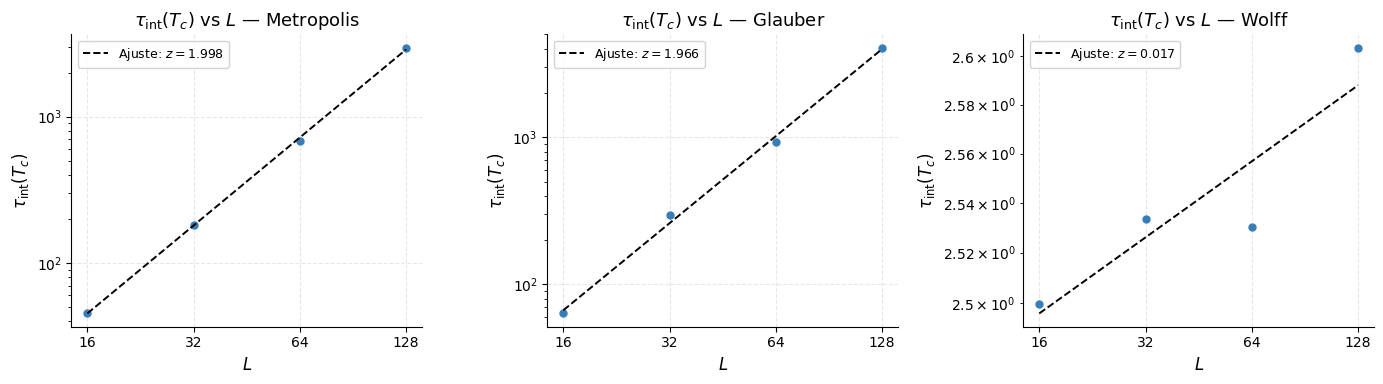

In [135]:
import matplotlib.ticker as mticker

L_arr = np.array(L_values, dtype=float)
log_L = np.log(L_arr)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (algo, df) in zip(axes, data.items()):
    tau_at_Tc = []
    for L in L_values:
        s = slice_L(df, L)
        f_tau = interp1d(s['T'].values, s['tau'].values,
                         kind='linear', bounds_error=False,
                         fill_value='extrapolate')
        tau_at_Tc.append(float(f_tau(TC_EXACT)))
    tau_arr = np.array(tau_at_Tc)
    z, intercept = np.polyfit(log_L, np.log(tau_arr), 1)
    L_fit = np.geomspace(L_arr[0], L_arr[-1], 50)
    ax.plot(L_arr, tau_arr, 'o', color='#377eb8', ms=5)
    ax.plot(L_fit, np.exp(intercept) * L_fit**z, 'k--', lw=1.4,
            label=fr'Ajuste: $z = {z:.3f}$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(L_arr)
    fmt = mticker.ScalarFormatter()
    fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlabel(r'$L$')
    ax.set_ylabel(r'$\tau_\mathrm{int}(T_c)$')
    ax.set_title(fr'$\tau_\mathrm{{int}}(T_c)$ vs $L$ — {algo}')
    ax.legend()
plt.tight_layout()
plt.savefig('Gráficas/tau_scaling.svg', bbox_inches='tight')
plt.show()

## 7. Determinación de $T_c$ mediante $\xi_L/L$ y $\tau_\text{int}$

Otra forma de calcular $T_c$ independiente del cumulante de Binder es:
1. Extraer los cruces de $\xi_L/L$ (ya que su valor es universal en $T_c$).
2. Interpolar el pico máximo del tiempo de autocorrelación $\tau_\text{int}$ (donde ocurre la máxima ralentización crítica) y extrapolarlo. (Solo apto para Metropolis/Glauber donde el exponente $z \approx 2.17$).

In [136]:
def tc_from_ratio_crossings(df, L_values, ycol, t_window=(2.1, 2.5)):
    """Cruces de y/L entre L consecutivos → Tc por extrapolación 1/L²."""
    crossings, inv_L2 = [], []
    for L1, L2 in zip(L_values[:-1], L_values[1:]):
        s1, s2 = slice_L(df, L1), slice_L(df, L2)
        f1 = PchipInterpolator(s1['T'].values, (s1[ycol] / L1).values,
                               extrapolate=False)
        f2 = PchipInterpolator(s2['T'].values, (s2[ycol] / L2).values,
                               extrapolate=False)

        T_lo = max(s1['T'].min(), s2['T'].min(), t_window[0])
        T_hi = min(s1['T'].max(), s2['T'].max(), t_window[1])
        Ts   = np.linspace(T_lo, T_hi, 2000)
        diff = f1(Ts) - f2(Ts)

        roots = []
        for j in range(len(diff) - 1):
            if diff[j] * diff[j+1] <= 0:
                try:
                    roots.append(brentq(lambda t: f1(t) - f2(t),
                                        Ts[j], Ts[j+1]))
                except ValueError:
                    pass
        if roots:
            crossings.append(float(np.median(roots)))
            inv_L2.append(1.0 / L2**2)

    if len(crossings) < 2:
        return None
    slope, tc_inf = np.polyfit(inv_L2, crossings, 1)
    return {'Tc_inf':    float(tc_inf),
            'Tc_mean':   float(np.mean(crossings)),
            'crossings': crossings}


def tc_from_tau_peak(df, L_values):
    """Localización del pico de τ_int por L → extrapolación 1/L² → Tc."""
    peaks  = [float(slice_L(df, L).loc[slice_L(df, L)['tau'].idxmax(), 'T'])
              for L in L_values]
    inv_L2 = [1.0 / L**2 for L in L_values]
    slope, tc_inf = np.polyfit(inv_L2, peaks, 1)
    return {'Tc_inf': float(tc_inf), 'peaks_mean': float(np.mean(peaks))}


print("--- Tc estimado por cruces de ξ_L / L ---")
for algo, df in data.items():
    r = tc_from_ratio_crossings(df, L_values, 'xi')
    if r is None:
        print(f"{algo:10s}: cruces insuficientes")
    else:
        print(f"{algo:10s}: Tc_inf = {r['Tc_inf']:.5f}  "
              f"(media cruces = {r['Tc_mean']:.5f})")

print("\n--- Tc estimado por pico de τ_int ---")
for algo, df in data.items():
    if algo == 'Wolff':
        print(f"{algo:10s}: ignorado (z ≈ 0, sin pico claro)")
        continue
    r = tc_from_tau_peak(df, L_values)
    print(f"{algo:10s}: Tc_inf = {r['Tc_inf']:.5f}  "
          f"(media picos = {r['peaks_mean']:.5f})")

--- Tc estimado por cruces de ξ_L / L ---
Metropolis: Tc_inf = 2.47810  (media cruces = 2.38769)
Glauber   : Tc_inf = 2.47661  (media cruces = 2.39274)
Wolff     : cruces insuficientes

--- Tc estimado por pico de τ_int ---
Metropolis: Tc_inf = 2.27260  (media picos = 2.26767)
Glauber   : Tc_inf = 2.26168  (media picos = 2.27786)
Wolff     : ignorado (z ≈ 0, sin pico claro)
